# Create ROI from a bounding box (EPSG:4326) → HEALPix ROI

This notebook converts a lon/lat **bounding box** into a **HEALPix (nested) ROI**, using `healpix-geo`.

## What you’ll get
- **child-level** HEALPix cell IDs that cover the bbox
- **parent-level** cell IDs (optional coarser ROI)
- a **boundary footprint** polygon for plotting / masking workflows


## Steps
1. **Imports & helper(s)**  
   Load dependencies and define helper function(s) used for boundary construction/plotting.

2. **Define bbox and compute child-level coverage**  
    Set (lon_min, lat_min, lon_max, lat_max) and child_level, then define a polygon from lon/lat vertices to focus the coverage on the target coastal area. For this use case, we chose a polygon that mainly covers the coastal area within the hypoxigenic region.

3. **Convert to parent level and save IDs**  
   Set `parent_level`, convert `child_ids → parent_ids`, deduplicate, and save to `parent_ids.npz`.

4. **Build outer boundary ring and export footprint**  
   Choose `edge_level`, compute an outer ring around the ROI, build a boundary polygon, and export to `outer_boundary.geojson`.5. Build/plot a boundary footprint, save them to geojson

## Tuning
If the ROI boundary looks “cut” or missing along edges, increase the boundary refinement.
Here we use :
- `edge_level = child_level - 2` 

## Output 
Save exported ROI Parent cell IDs / Parent level(`parent_ids.npz`)  and footprint GeoJSON (`outer_boundary.geojson`) so `Prep_regrid.ipynb` can reuse them for masking/subsetting.


## Step 1 — Imports and helper functions


In [1]:
!pip install grid4earth

In [2]:
import geopandas as gpd
import healpix_geo
import numpy as np
from shapely.geometry import Polygon, box
from shapely.ops import transform, unary_union

In [3]:
def get_boundary(cell_ids, level, plot=False):
    lonv, latv = healpix_geo.nested.vertices(cell_ids, depth=level, ellipsoid="WGS84")

    def _unwrap_dateline(lons):
        lons = np.asarray(lons, dtype=float).copy()
        if (np.nanmax(lons) - np.nanmin(lons)) > 180:
            lons[lons < 0] += 360
        return lons

    polys = []
    for i in range(lonv.shape[0]):
        xs = _unwrap_dateline(lonv[i])
        ys = latv[i]
        # print(lonv[i],xs)
        coords = list(zip(xs, ys))
        if coords[0] != coords[-1]:
            coords.append(coords[0])
        polys.append(Polygon(coords))

    footprint = unary_union(polys)  # Polygon or MultiPolygon

    # Wrap final footprint to [-180, 180] for plotting/overlay with lon=-180..180 data
    footprint_180 = transform(wrap_lon_180, footprint)

    if plot:
        gdf_fp = gpd.GeoDataFrame(
            {"name": ["footprint"]},
            geometry=[footprint_180],
            crs="EPSG:4326",
        )
        ax = gdf_fp.plot(edgecolor="k", facecolor="none", linewidth=2)
        ax.set_aspect("equal")

    return footprint_180


def wrap_lon_180(x, y, z=None):
    x = ((np.asarray(x) + 180) % 360) - 180
    return (x, y) if z is None else (x, y, z)

## Step 2 — Define the ROI bounding box


In [4]:
# Find out child (data projected ) cell_ids

# Define The child_level
child_level = 13


# Define The ROI bbox in  (lon/lat)
lon_min, lon_max = -2.8, -1.97333
lat_min, lat_max = 47.04367, 47.31558
bbox = (lon_min, lat_min, lon_max, lat_max)


child_ids, _, _ = healpix_geo.nested.zone_coverage(
    bbox=bbox,
    depth=child_level,
    ellipsoid="WGS84",
    flat=True,  # returns a 1D array of cell ids
)
print(f"N level {child_level} cells covering former bbox: {child_ids.size}")



lon_min, lon_max = -3.3, -1.97333
lat_min, lat_max = 47.04367, 47.6
lat_min, lat_max = 47.04367, 47.7

bbox = (lon_min, lat_min, lon_max, lat_max)


# Find out child (data projected ) cell_ids

child_ids, _, _ = healpix_geo.nested.zone_coverage(
    bbox=bbox,
    depth=child_level,
    ellipsoid="WGS84",
    flat=True,  # returns a 1D array of cell ids
)
print(f"N level {child_level} cells covering bbox: {child_ids.size}")


# Convert bbox to polygon vertices: (lon, lat)

# Important: close the polygon by repeating the first point at the end

vertices = np.array([

    [lon_min, lat_min],

    [lon_max, lat_min],

    [lon_max, lat_max],

    [lon_min, lat_max],

    [lon_min, lat_min],

])

vertices = np.array([

    [-3.30, 47.48],  # left / northwest

    [-3.24, 47.58],

    [-3.15, 47.66],

    [-3.02, 47.70],

    [-2.86, 47.68],

    [-2.65, 47.61],

    [-2.42, 47.50],

    [-2.22, 47.42],

    [-2.02, 47.34],

    [-1.90, 47.25],

    [-1.94, 47.12],

    [-2.10, 47.04],

    [-2.35, 47.08],

    [-2.58, 47.16],

    [-2.78, 47.24],

    [-3.00, 47.30],

    [-3.20, 47.38],

    [-3.30, 47.48],  # close polygon

])

# Find child HEALPix cell ids covering the polygon

child_ids, depths, fully_covered = healpix_geo.nested.polygon_coverage(

    vertices=vertices,

    depth=child_level,

    ellipsoid="WGS84",

    flat=True,

)
print(f"N level {child_level} cells covering polygon: {child_ids.size}")


N level 13 cells covering former bbox: 3218
N level 13 cells covering bbox: 11966
N level 13 cells covering polygon: 6658


## Step 3 — Compute HEALPix coverage (child → parent) and save IDs


N parent level 10 cells: 140


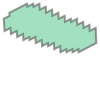

In [5]:
# Find out full parent cell id corresponding to the child (data projected ) cell_ids

parent_level = 10

# 2) Map child ids to parent ids
parent_ids = healpix_geo.nested.zoom_to(
    child_ids,
    depth=child_level,
    new_depth=parent_level,
)
parent_ids, counts = np.unique(parent_ids, return_counts=True)

print(f"N parent level {parent_level} cells: {parent_ids.size}")
# save parent_ids
np.savez(
    "parent_ids.npz",
    parent_ids=parent_ids,
    parent_level=parent_level,
)
# plot the parent cell ids
get_boundary(parent_ids, parent_level)

## Step 4 — Build boundary footprint (parent + outer ring) and export GeoJSON


In [6]:
# translate these parent_cell ids in edge_level.
edge_level = child_level - 2
print("boundary region is in level", edge_level)
##keep only the outer boundary cells from edges_ids
# edges_ids = healpix_geo.nested.internal_boundary(edge_level, edges_ids)
edges_ids = healpix_geo.nested.zoom_to(
    #    boundary_parents_ids,
    parent_ids,
    depth=parent_level,
    new_depth=edge_level,
)
edges_ids = np.unique(edges_ids, return_counts=False)
print(f"N edges level {edge_level} cells: {edges_ids.size}")

# get_boundary(edges_ids,edge_level)

boundary region is in level 11
N edges level 11 cells: 560


N edges level 11 outer edges cells: 720


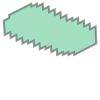

In [7]:
# find N+1 neighbour in edge_level
outer_edges_ids = np.unique(
    healpix_geo.nested.kth_neighbourhood(
        edges_ids, edge_level, ring=1, num_threads=0
    ),  # return_counts=True
)
print(f"N edges level {edge_level} outer edges cells: {outer_edges_ids.size}")
outer_boundary = get_boundary(outer_edges_ids, edge_level)
outer_boundary

In [8]:
gdf = gpd.GeoDataFrame(
    {"name": ["outer_boundary"]},
    geometry=[outer_boundary],
    crs="EPSG:4326",
)

gdf.to_file("outer_boundary.geojson", driver="GeoJSON")

<GeoAxes: >

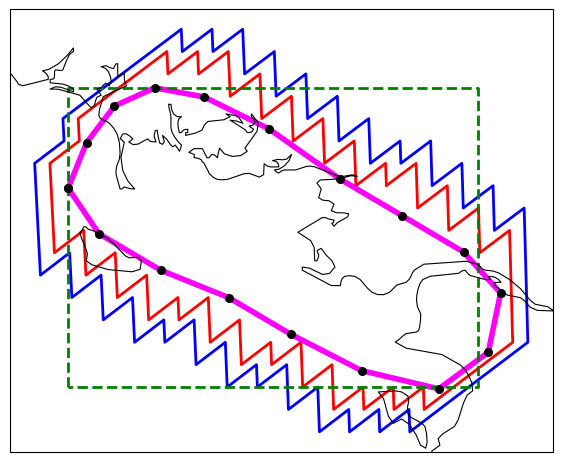

In [12]:
import cartopy.crs as ccrs
import geopandas as gpd
import matplotlib.pyplot as plt

fig, ax = plt.subplots(
    subplot_kw={"projection": ccrs.PlateCarree()},
    figsize=(7, 7),
)

gdf_fp = gpd.GeoDataFrame(
    {"name": ["parent_ids"]},
    geometry=[get_boundary(parent_ids, parent_level, plot=False)],
    crs="EPSG:4326",
)
gdf_fp.plot(ax=ax, edgecolor="red", facecolor="none", linewidth=2)

gdf.plot(ax=ax, edgecolor="blue", facecolor="none", linewidth=2)

gdf_bbox = gpd.GeoDataFrame(
    {"name": ["bbox"]},
    geometry=[box(*bbox)],
    crs="EPSG:4326",
)
gdf_bbox.plot(
    ax=ax,
    edgecolor="green",
    facecolor="none",
    linewidth=2,
    linestyle="--",
)

gdf_polygon = gpd.GeoDataFrame(
    {"name": ["polygon"]},
    geometry=[Polygon(vertices)],
    crs="EPSG:4326",
)
gdf_polygon.plot(
    ax=ax,
    edgecolor="magenta",
    facecolor="none",
    linewidth=4,
)

ax.scatter(
    vertices[:, 0],
    vertices[:, 1],
    color="black",
    s=30,
    zorder=10,
)

ax.coastlines(resolution="10m", linewidth=0.8)
ax.set_aspect("equal")